
Testing OpenAI Connection...

Why did the scarecrow win an award? 

Because he was outstanding in his field!


/Users/utsabchakraborty/Documents/Edureka_May2026/Backup_LG/venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


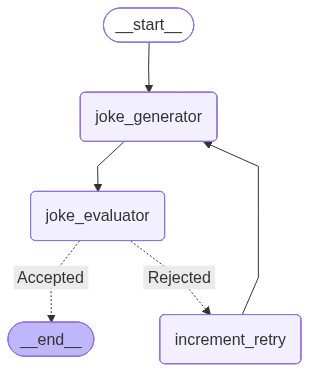



RUNNING EVALUATOR-OPTIMIZER WORKFLOW

--- GENERATOR NODE RUNNING ---
Retry Count: 0

Generating Initial Joke...

Generated Joke:

Why did the developing country refuse the trade agreement? 

Because they didn’t want to "develop" a dependency on someone else's "bargain"!

--- EVALUATOR NODE RUNNING ---

Evaluating Joke:

Why did the developing country refuse the trade agreement? 

Because they didn’t want to "develop" a dependency on someone else's "bargain"!

Evaluation Result:

Grade: not funny
Feedback: The joke relies on wordplay that may not resonate with all audiences, especially if they don't find the terms 'develop' and 'bargain' humorous. To improve it, consider simplifying the joke or making the punchline more relatable. For example: "Why did the developing country refuse the trade agreement? Because they didn't want to trade their independence for a bargain!" This maintains the theme while being more straightforward and impactful.

--- ROUTING DECISION ---
Evaluation: not f

In [1]:
"""
====================================================================
LANGGRAPH EVALUATOR-OPTIMIZER WORKFLOW
====================================================================

CONCEPTS TAUGHT:
----------------
1. Evaluator-Optimizer Pattern
2. Iterative Refinement Loops
3. Self-Improving AI Systems
4. Feedback-Based Optimization
5. Conditional Routing
6. Structured Outputs
7. Stateful Graph Execution
8. Validation & Quality Control
9. Human-like Revision Cycles
10. Enterprise AI Refinement Pipelines
11. Dynamic Workflow Loops
12. Retry Mechanisms
13. Observability & Streaming
14. Prompt Optimization Workflows
15. LangGraph Cyclic Graphs

WHAT IS EVALUATOR-OPTIMIZER?
----------------------------
One LLM:
    Generates output

Another LLM:
    Evaluates output

The evaluator:
- checks quality
- gives feedback
- triggers refinement loop

The generator:
- improves output using feedback

This continues until:
- quality is acceptable
- stopping criteria reached

WHY THIS PATTERN MATTERS:
-------------------------
This mimics human workflows:
- draft
- review
- revise
- improve
- finalize

VERY useful for:
- writing systems
- coding agents
- report generation
- QA pipelines
- AI reviewers
- content optimization

ARCHITECTURE TYPE:
------------------
Cyclic Evaluator-Optimizer Workflow

WORKFLOW:
---------
Generator
    ↓
Evaluator
    ↓
Accepted? ── YES ──→ END
    │
    NO
    │
Feedback Loop
    │
Generator Retry
    ↓
Evaluator

IMPORTANT LANGGRAPH CONCEPT:
----------------------------
Traditional chains struggle with loops.

LangGraph naturally supports:
- cyclic workflows
- iterative refinement
- dynamic retries

"""

# ==============================================================
# STEP 1 — IMPORTS
# ==============================================================

import os

from dotenv import load_dotenv

# ==============================================================
# STEP 2 — LOAD ENV VARIABLES
# ==============================================================

load_dotenv()

if not os.getenv("OPENAI_API_KEY"):

    raise ValueError(
        "OPENAI_API_KEY missing in .env file"
    )

os.environ["OPENAI_API_KEY"] = os.getenv(
    "OPENAI_API_KEY"
)

# Optional LangSmith tracing
os.environ["LANGCHAIN_PROJECT"] = os.getenv(
    "LANGCHAIN_PROJECT",
    "LangGraph-Evaluator-Optimizer"
)

os.environ["LANGCHAIN_TRACING_V2"] = os.getenv(
    "LANGCHAIN_TRACING_V2",
    "true"
)

os.environ["LANGCHAIN_API_KEY"] = os.getenv(
    "LANGCHAIN_API_KEY",
    ""
)

# ==============================================================
# STEP 3 — CREATE OPENAI LLM
# ==============================================================

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7
)

# ==============================================================
# STEP 4 — TEST LLM CONNECTION
# ==============================================================

print("\nTesting OpenAI Connection...\n")

try:

    test_result = llm.invoke(
        "Tell me a short joke."
    )

    print(test_result.content)

except Exception as e:

    print("LLM Connection Error:", e)

# ==============================================================
# STEP 5 — DEFINE GRAPH STATE
# ==============================================================
# IMPORTANT CONCEPT:
#
# Shared state enables communication
# across workflow nodes.

from typing_extensions import TypedDict

class State(TypedDict):

    # User topic
    topic: str

    # Generated joke
    joke: str

    # Evaluator feedback
    feedback: str

    # Final evaluation
    funny_or_not: str

    # Retry tracking
    retry_count: int

# ==============================================================
# STEP 6 — STRUCTURED OUTPUTS
# ==============================================================
# IMPORTANT CONCEPT:
#
# Structured outputs create:
# - reliable evaluations
# - predictable routing
# - safer workflows

from typing_extensions import Literal

from pydantic import (
    BaseModel,
    Field
)

# ==============================================================
# FEEDBACK SCHEMA
# ==============================================================

class Feedback(BaseModel):

    grade: Literal[
        "funny",
        "not funny"
    ] = Field(

        description=
        "Decide if joke is funny or not."
    )

    feedback: str = Field(

        description=
        """
        Improvement suggestions
        if joke is not funny.
        """
    )

# ==============================================================
# STRUCTURED EVALUATOR
# ==============================================================

evaluator = llm.with_structured_output(
    Feedback
)

# ==============================================================
# STEP 7 — GENERATOR NODE
# ==============================================================
# Generator creates jokes.
#
# IMPORTANT:
# Generator uses evaluator feedback
# to improve outputs.

def joke_generator(state: State):

    """
    Generate or improve joke.
    """

    print("\n--- GENERATOR NODE RUNNING ---")

    topic = state["topic"]

    feedback = state.get(
        "feedback",
        ""
    )

    retry_count = state.get(
        "retry_count",
        0
    )

    print(f"Retry Count: {retry_count}")

    # ==========================================================
    # FIRST ATTEMPT
    # ==========================================================

    if not feedback:

        print("\nGenerating Initial Joke...\n")

        prompt = f"""
        Write a funny joke about:

        {topic}

        REQUIREMENTS:
        - concise
        - witty
        - clever
        - clean humor
        """

    # ==========================================================
    # REFINEMENT ATTEMPT
    # ==========================================================
    # Generator improves using evaluator feedback.

    else:

        print("\nImproving Joke Using Feedback...\n")

        prompt = f"""
        Improve this joke based on feedback.

        TOPIC:
        {topic}

        FEEDBACK:
        {feedback}

        REQUIREMENTS:
        - improve humor
        - increase creativity
        - maintain clarity
        """

    response = llm.invoke(prompt)

    print("Generated Joke:\n")

    print(response.content)

    return {

        "joke": response.content
    }

# ==============================================================
# STEP 8 — EVALUATOR NODE
# ==============================================================
# IMPORTANT CONCEPT:
#
# Evaluator acts like:
# - reviewer
# - critic
# - quality controller

def joke_evaluator(state: State):

    """
    Evaluate joke quality.
    """

    print("\n--- EVALUATOR NODE RUNNING ---")

    joke = state["joke"]

    print("\nEvaluating Joke:\n")

    print(joke)

    # ==========================================================
    # Structured Evaluation
    # ==========================================================

    evaluation = evaluator.invoke(

        f"""
        Evaluate this joke carefully.

        JOKE:
        {joke}

        Decide:
        - funny
        - not funny

        If not funny:
        provide improvement feedback.
        """
    )

    print("\nEvaluation Result:\n")

    print("Grade:", evaluation.grade)

    print("Feedback:", evaluation.feedback)

    return {

        "funny_or_not":
        evaluation.grade,

        "feedback":
        evaluation.feedback
    }

# ==============================================================
# STEP 9 — RETRY COUNTER NODE
# ==============================================================
# Tracks optimization attempts.

def increment_retry(state: State):

    """
    Increment retry count.
    """

    current_retry = state.get(
        "retry_count",
        0
    )

    new_retry = current_retry + 1

    print(
        f"\nRetry incremented to: {new_retry}"
    )

    return {

        "retry_count": new_retry
    }

# ==============================================================
# STEP 10 — ROUTING FUNCTION
# ==============================================================
# VERY IMPORTANT LANGGRAPH CONCEPT:
#
# Conditional routing enables:
# - loops
# - retries
# - intelligent execution
# - dynamic workflows

def route_joke(state: State):

    """
    Decide whether to:
    - accept joke
    - retry optimization
    """

    print("\n--- ROUTING DECISION ---")

    result = state["funny_or_not"]

    retry_count = state.get(
        "retry_count",
        0
    )

    print("Evaluation:", result)

    print("Retry Count:", retry_count)

    # ==========================================================
    # ACCEPT OUTPUT
    # ==========================================================

    if result == "funny":

        print("\nJoke Accepted")

        return "Accepted"

    # ==========================================================
    # LOOP SAFEGUARD
    # ==========================================================
    # Prevent infinite optimization loops.

    if retry_count >= 3:

        print(
            "\nMaximum retries reached"
        )

        return "Accepted"

    # ==========================================================
    # RETRY OPTIMIZATION
    # ==========================================================

    print("\nJoke Rejected")

    return "Rejected"

# ==============================================================
# STEP 11 — BUILD LANGGRAPH WORKFLOW
# ==============================================================

from langgraph.graph import (
    StateGraph,
    START,
    END
)

workflow = StateGraph(State)

# ==============================================================
# STEP 12 — ADD NODES
# ==============================================================

workflow.add_node(
    "joke_generator",
    joke_generator
)

workflow.add_node(
    "joke_evaluator",
    joke_evaluator
)

workflow.add_node(
    "increment_retry",
    increment_retry
)

# ==============================================================
# STEP 13 — ADD EDGES
# ==============================================================

workflow.add_edge(
    START,
    "joke_generator"
)

workflow.add_edge(
    "joke_generator",
    "joke_evaluator"
)

# ==============================================================
# CONDITIONAL ROUTING
# ==============================================================
# VERY IMPORTANT CONCEPT:
#
# Evaluator controls workflow direction.

workflow.add_conditional_edges(

    "joke_evaluator",

    route_joke,

    {
        "Accepted": END,

        "Rejected": "increment_retry"
    }
)

# ==============================================================
# CYCLIC OPTIMIZATION LOOP
# ==============================================================
# LangGraph naturally supports loops.

workflow.add_edge(
    "increment_retry",
    "joke_generator"
)

# ==============================================================
# STEP 14 — COMPILE GRAPH
# ==============================================================

app = workflow.compile()

# ==============================================================
# STEP 15 — VISUALIZE GRAPH
# ==============================================================

from IPython.display import (
    Image,
    display
)

try:

    display(

        Image(

            app.get_graph()
            .draw_mermaid_png()

        )
    )

except Exception as e:

    print(
        "Visualization Error:",
        e
    )

# ==============================================================
# STEP 16 — EXECUTE WORKFLOW
# ==============================================================

print("\n")
print("=" * 70)
print("RUNNING EVALUATOR-OPTIMIZER WORKFLOW")
print("=" * 70)

initial_state = {

    "topic":
    """
    A developing country refusing
    a trade agreement with a developed country
    """,

    "joke": "",

    "feedback": "",

    "funny_or_not": "",

    "retry_count": 0
}

final_state = app.invoke(
    initial_state
)

# ==============================================================
# STEP 17 — PRINT FINAL RESULT
# ==============================================================

print("\n")
print("=" * 70)
print("FINAL OPTIMIZED JOKE")
print("=" * 70)

print(final_state["joke"])

print("\n")
print("=" * 70)
print("FINAL EVALUATION")
print("=" * 70)

print(final_state["funny_or_not"])

print("\n")
print("=" * 70)
print("FINAL FEEDBACK")
print("=" * 70)

print(final_state["feedback"])

# ==============================================================
# STEP 18 — STREAM EXECUTION
# ==============================================================
# VERY IMPORTANT CONCEPT:
#
# stream() enables observability.
#
# Critical for debugging workflows.

print("\n")
print("=" * 70)
print("STREAMING EXECUTION")
print("=" * 70)

for event in app.stream(
    initial_state
):

    print(event)

# ==============================================================
# STEP 19 — IMPORTANT TEACHING SUMMARY
# ==============================================================
#
# WHAT THIS EXAMPLE TAUGHT:
#
# 1. Evaluator-Optimizer Pattern
# 2. Iterative Refinement
# 3. Feedback Loops
# 4. Conditional Routing
# 5. Cyclic Graphs
# 6. Stateful Execution
# 7. Structured Outputs
# 8. Quality Control Pipelines
# 9. Self-Improving Systems
# 10. Observability
#
# MOST IMPORTANT TAKEAWAY:
#
# Evaluator-optimizer workflows allow
# AI systems to iteratively improve outputs
# using feedback loops.
#
# This mimics human workflows:
# - draft
# - review
# - revise
# - improve
#
# WHY THIS MATTERS:
#
# Enterprise AI systems often require:
# - quality control
# - refinement
# - validation
# - optimization
#
# This pattern is foundational for:
# - coding agents
# - report generation
# - AI reviewers
# - autonomous QA systems
# - iterative writing systems
#